In [1]:
import pickle
import os

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
import healpy as hp

import arviz as az
import jax
from jax import numpy as jnp
import numpyro.distributions as dist

from embers_passes import SphericalSpline, eval_spline_batch, make_disk_mask, \
      make_flat_index, make_knots_from_grid, scatter_coeffs, eval_spline_samples, \
      healpix_to_pyuvdata, bin_chunk, PassFile, chunk_passes, prep_mwa_beam, \
      get_res, get_pol_ind, get_above_horizon, fill_map, to_db

import cmasher as cmr

from pathlib import Path

import corner
import xarray as xr

import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

/Users/mwilensky/miniconda3/envs/satellite_beams/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mwilensky/miniconda3/envs/satellite_beams/lib/python3.14/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
def get_chunk_stats(samples):
    samples = jnp.asarray(samples)
    n = len(samples)

    mean = samples.mean(axis=0)
    std = samples.std(ddof=1, axis=0)
    sem = std / jnp.sqrt(n)

    return {"mean": mean, "std": std, "sem": sem}

def contributing_pass_count_map(passes, chunk, nside):
    """
    Number of independent passes contributing to each HEALPix pixel.

    A pass contributes at most once to a given pixel, regardless of how many
    samples from that pass land in the pixel.
    """
    npix = hp.nside2npix(nside)
    n_pass_map = np.zeros(npix, dtype=np.int32)

    for pass_index in chunk:
        pass_record = passes[pass_index]

        alt_deg = np.asarray(pass_record.alt_deg, dtype=float)
        az_deg = np.asarray(pass_record.az_deg, dtype=float)
        power_db = np.asarray(pass_record.power_db, dtype=float)

        if not (
            alt_deg.shape
            == az_deg.shape
            == power_db.shape
        ):
            raise ValueError(
                "alt_deg, az_deg, and power_db must have matching shapes."
            )

        valid = (
            np.isfinite(alt_deg)
            & np.isfinite(az_deg)
            & np.isfinite(power_db)
            & (alt_deg > 0.0)
        )

        if not np.any(valid):
            continue

        theta = np.radians(90.0 - alt_deg[valid])
        phi = np.radians(az_deg[valid])

        pixels = hp.ang2pix(
            nside,
            theta,
            phi,
        )

        # Each independent pass counts only once per pixel.
        n_pass_map[np.unique(pixels)] += 1

    return n_pass_map

def fit_single_pass_uncertainty_cut(
    count_maps,
    mad_maps,
    median_sem_maps,
    n_pass_maps,
    min_count=3,
    robust_z_cut=-3.0,
):
    """
    Estimate a robust lower-tail uncertainty cut for single-pass pixels.

    The distribution is defined in log10(sigma), pooling valid single-pass
    pixels across all chunks.

    Returns
    -------
    metadata : dict
        Median/scatter of log10(sigma), robust-z threshold, and equivalent
        sigma threshold in dB.
    """
    pooled_log_sigma = []

    for count_map, mad_map, sem_map, n_pass_map in zip(
        count_maps,
        mad_maps,
        median_sem_maps,
        n_pass_maps,
    ):
        count_map = np.asarray(count_map)
        n_pass_map = np.asarray(n_pass_map)

        sigma = np.sqrt(
            np.asarray(mad_map, dtype=np.float64) ** 2
            + np.asarray(sem_map, dtype=np.float64) ** 2
        )

        valid_single = (
            (count_map >= min_count)
            & (n_pass_map == 1)
            & np.isfinite(sigma)
            & (sigma > 0)
        )

        pooled_log_sigma.append(
            np.log10(sigma[valid_single])
        )

    pooled_log_sigma = np.concatenate(
        pooled_log_sigma
    )

    if pooled_log_sigma.size < 10:
        raise ValueError(
            "Too few valid single-pass pixels to define a robust "
            f"uncertainty cut ({pooled_log_sigma.size} found)."
        )

    median_log_sigma = np.median(
        pooled_log_sigma
    )

    # Gaussian-equivalent scatter estimated from MAD.
    robust_sigma_log = (
        1.482602218505602
        * np.median(
            np.abs(
                pooled_log_sigma
                - median_log_sigma
            )
        )
    )

    if (
        not np.isfinite(robust_sigma_log)
        or robust_sigma_log <= 0
    ):
        raise ValueError(
            "Could not estimate a finite positive robust scatter."
        )

    log_sigma_cut = (
        median_log_sigma
        + robust_z_cut * robust_sigma_log
    )

    sigma_cut_db = 10.0 ** log_sigma_cut

    return {
        "robust_z_cut": float(robust_z_cut),
        "pooled_n_single_pass_pixels": int(
            pooled_log_sigma.size
        ),
        "median_log10_sigma": float(
            median_log_sigma
        ),
        "robust_sigma_log10_sigma": float(
            robust_sigma_log
        ),
        "sigma_cut_db": float(
            sigma_cut_db
        ),
    }

def single_pass_low_uncertainty_mask(
    count_map,
    mad_map,
    median_sem_map,
    n_pass_map,
    cut_metadata,
    min_count=3,
):
    """
    Flag anomalously low-uncertainty single-pass pixels.

    Returns
    -------
    mask : bool array
        True for pixels to exclude.
    robust_z : float array
        Robust z-score in log10(sigma); NaN elsewhere.
    sigma : float array
        Combined per-pixel uncertainty.
    """
    count_map = np.asarray(count_map)
    n_pass_map = np.asarray(n_pass_map)

    sigma = np.sqrt(
        np.asarray(mad_map, dtype=np.float64) ** 2
        + np.asarray(median_sem_map, dtype=np.float64) ** 2
    )

    one_pass_valid = (
        (count_map >= min_count)
        & (n_pass_map == 1)
        & np.isfinite(sigma)
        & (sigma > 0)
    )

    robust_z = np.full(
        sigma.shape,
        np.nan,
        dtype=np.float64,
    )

    robust_z[one_pass_valid] = (
        (
            np.log10(
                sigma[one_pass_valid]
            )
            - cut_metadata[
                "median_log10_sigma"
            ]
        )
        / cut_metadata[
            "robust_sigma_log10_sigma"
        ]
    )

    mask = (
        one_pass_valid
        & (
            robust_z
            < cut_metadata[
                "robust_z_cut"
            ]
        )
    )

    return mask, robust_z, sigma

import xarray as xr
import numpy as np

def posterior_to_dict(dt: xr.DataTree, Nsamp_total=16000) -> dict[str, jnp.ndarray]:
    """
    Extract the `.posterior` group from an ArviZ-style xarray.DataTree
    and convert it into a dictionary of NumPy arrays.

    Parameters
    ----------
    dt : xarray.DataTree
        A DataTree with a "posterior" child node (as produced by
        arviz.from_pymc3, arviz.from_cmdstanpy, etc., when converted
        to a DataTree/InferenceData object).

    Returns
    -------
    dict[str, np.ndarray]
        Mapping from variable name to its underlying array of samples,
        with dimensions typically (chain, draw, *shape).
    """
    if "posterior" not in dt.children:
        raise KeyError("The provided DataTree has no 'posterior' group.")

    # dt["posterior"] is itself a DataTree node; .to_dataset() (or .ds)
    # gives the underlying xarray.Dataset
    posterior_ds = dt["posterior"].to_dataset()

    return {var_name: jnp.array(da.values).reshape(Nsamp_total, -1) for var_name, da in posterior_ds.data_vars.items()}



In [3]:
indir = "/Users/mwilensky/projects/satellite_beams/resample"
Nday = 20
Nchunk = 80 // Nday

indir += f"/{Nday}_day/rf0"

tile = "06"
pol = "XX"

indir += f"/S{tile}/{pol}/time_jackknife"


In [4]:
SVI = False

chunked_samps = []

for chunk in range(Nchunk):
    indir_this_chunk = f"{indir}/chunk{chunk}"
    if SVI:
        with open(f"{indir_this_chunk}/svi_laplace_samps.pkl", "rb") as svi_samps_file:
            chunked_samps.append(pickle.load(svi_samps_file))
    else:
        chunked_samps.append(posterior_to_dict(az.from_netcdf(f"{indir_this_chunk}/mcmc_out.nc")))

In [5]:
chunked_stats = jax.tree.map(get_chunk_stats, chunked_samps)

def get_tension(i, j, param_name):
    mean_i, mean_j = chunked_stats[i][param_name]["mean"], chunked_stats[j][param_name]["mean"]
    std_i, std_j = chunked_stats[i][param_name]["std"], chunked_stats[j][param_name]["std"]


    # Welch-style z/t statistic on the difference of means
    std_diff = jnp.sqrt(std_i**2 + std_j**2)
    z = (mean_i - mean_j) / std_diff

    return z

In [6]:
mwa_beamfile = "/Users/mwilensky/projects/SSINS/mwa_full_embedded_element_pattern.h5"
beam = prep_mwa_beam(mwa_beamfile)
pol_ind = get_pol_ind(beam, pol)

Only one available frequency in freq_range.


In [7]:
path = Path(f"../passes/rf0/S{tile}{pol}_rf0{pol}_passes.h5")
pf = PassFile(path)
# FIXME: Only 0 pointing
passes = pf.read_passes(pointing=0)
Npass_total = len(passes)
chunk_sec = 86400 * Nday


chunks, bins_edges, bin_centers = chunk_passes(passes, chunk_sec)
nside = 32


def get_chunked_quantities(passes, chunk_inds):
    median_map, count_map, mad_map, median_sem_map = bin_chunk(
    passes, chunk_inds
)
    n_pass_map = contributing_pass_count_map(
        passes, chunk_inds, nside=32
    )

    cut_metadata = fit_single_pass_uncertainty_cut(
        [count_map], [mad_map], [median_sem_map], [n_pass_map]
    )

    mask, robust_z, sigma = single_pass_low_uncertainty_mask(
        count_map, mad_map, median_sem_map, n_pass_map, cut_metadata
    )

    # No great way to pass this mask through healpix_to_pyuvdata -- set counts to 0
    count_map[mask] = 0

    median_values, za_rad, az_rad = healpix_to_pyuvdata(median_map)
    count_values, _, _ = healpix_to_pyuvdata(count_map)
    mad_values, _, _ = healpix_to_pyuvdata(mad_map)
    median_sem_values, _, _ = healpix_to_pyuvdata(median_sem_map)

    xspline, yspline = sphere_to_orth(za_rad, az_rad) # For spline plotting later

    count_gt_2 = count_values > 2 # MAD estimates completely untrustworthy for counts less than 3
    median_values = median_values[count_gt_2]
    za_rad = za_rad[count_gt_2]
    az_rad = az_rad[count_gt_2]
    mad_values = mad_values[count_gt_2]
    count_values = count_values[count_gt_2]
    median_sem_values = median_sem_values[count_gt_2]

    dat_coord_1, dat_coord_2 = sphere_to_orth(za_rad, az_rad)

    res, model_beam = get_res(az_rad, za_rad, median_values, pol_ind, beam)

    # Redoes some computation internal to above functions for purposes of
    # making plotting possible
    _, _, above_horizon = get_above_horizon(nside)
    inds_kept = np.logical_and(above_horizon, count_map > 2)

    return {
        "median_values": median_values,
        "za_rad": za_rad,
        "az_rad": az_rad,
        "mad_values": mad_values,
        "count_values": count_values,
        "median_sem_values": median_sem_values,
        "dat_coord_1": dat_coord_1,
        "dat_coord_2": dat_coord_2,
        "res": res,
        "model_beam": model_beam,
        "inds_kept": inds_kept,
        "above_horizon": above_horizon,
        "xspline": xspline,
        "yspline": yspline
    }

def sphere_to_orth(za_rad, az_rad):
    dat_coord_1 = jnp.sin(za_rad) * jnp.cos(az_rad)
    dat_coord_2 = jnp.sin(za_rad) * jnp.sin(az_rad)
    return dat_coord_1,dat_coord_2

chunk_data_containers = []
for chunk_num in range(Nchunk):
    chunk_inds = chunks[chunk_num]
    chunk_data_containers.append(get_chunked_quantities(passes, chunk_inds))

In [8]:
def prep_spline_params(beam, ortho_knots=False, spice_variant=0):
    if ortho_knots:
        if spice_variant:
            if spice_variant > 3: # Increasing density only at horizon
                interval_1 = np.arange(-1, -0.6, 0.05 / (2**(spice_variant - 3)))
                interval_2 = np.arange(-0.6, -0.4, 0.025)
                interval_3 = np.arange(-0.4, 0., 0.1)
            elif spice_variant == 3: # Twice as dense except in main lobe
                interval_1 = np.arange(-1., -0.6, 0.025)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.1)
            elif spice_variant == 2: # Twice as dense except at horizon
                interval_1 = np.arange(-1., -0.6, 0.05)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.05)
            else: # Twice as dense everywhere
                interval_1 = np.arange(-1., -0.6, 0.025)
                interval_2 = np.arange(-0.6, -0.4, 0.0125)
                interval_3 = np.arange(-0.4, 0., 0.05)
        else:
            interval_1 = np.arange(-1., -0.6, 0.05)
            interval_2 = np.arange(-0.6, -0.4, 0.025)
            interval_3 = np.arange(-0.4, 0., 0.1)

        base_knots = np.concatenate([
            interval_1, 
            interval_2, 
            interval_3,
            np.atleast_1d([0.]),
            -np.flip(interval_3),
            -np.flip(interval_2),
            -np.flip(interval_1)
        ])

        t_x, t_y, p, q, n_x, n_y = make_knots_from_grid(base_knots, base_knots)
        Nparam = n_x * n_y

        return t_x, t_y, p, q, n_x, n_y, Nparam
    else:
        theta_param = beam.axis2_array[1::10] # avoid the origin by a quarter degree
        phi_param = beam.axis1_array[::10]

        # ONCE, outside the model:
        t_theta, t_phi, p, q, n_th, n_ph = make_knots_from_grid(theta_param, phi_param)
        Nparam = n_th * n_ph
        return t_theta, t_phi, p, q, n_th, n_ph, Nparam

t_x, t_y, p, q, n_x, n_y, _= prep_spline_params(None, ortho_knots=True)
knot_mask = make_disk_mask(t_x, t_y, p, q)           # (n_x, n_y) bool, numpy
knot_ij, Nparam = make_flat_index(knot_mask)            # static arrays

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


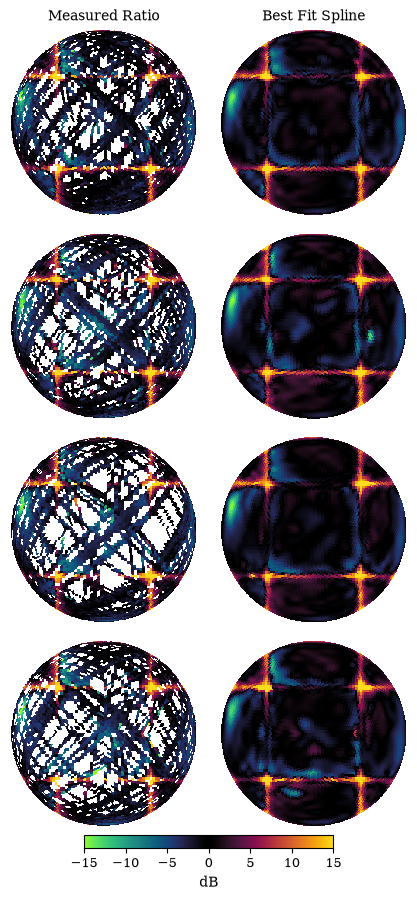

In [9]:
wildfire_top = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1).with_extremes(under="white")
fig = plt.figure(figsize=(4.2, 8.4))
npix = hp.nside2npix(nside)

PLOT_RES = True
if PLOT_RES:
    vmax = 15
    vmin = -vmax
    cmap = cmr.wildfire
else:
    vmax = 0
    vmin=-75
    cmap = wildfire_top


paper_plot_dir = "/Users/mwilensky/projects/satellite_beams/paper_plots"
paper_plot_dir = f"/Users/mwilensky/projects/satellite_beams/paper_plots/rf0/S{tile}/{pol}"
if not os.path.exists(paper_plot_dir):
    os.makedirs(paper_plot_dir)

orthview_kwargs = {
    "rot": (0, 90, 180),
    "half_sky": True,
    "badcolor": "white",
    "cbar": False,
    "title": None
}

def add_FEE_to_model(chunk_data, model):
    az_for_uvb = np.arctan2(chunk_data["yspline"], chunk_data["xspline"]) % (2 * np.pi)
    za_for_uvb = np.arcsin(np.sqrt(chunk_data["yspline"]**2 + chunk_data["xspline"]**2))
    beam_at_spline_locs = beam.interp(
            az_array=az_for_uvb,
            za_array=za_for_uvb,
        )[0][0, pol_ind, 0]
    beam_at_spline_locs = to_db(beam_at_spline_locs)
    model += beam_at_spline_locs
    return model

all_axes = []
chunk_models = []

for chunk_num, chunk_data in enumerate(chunk_data_containers):
    if PLOT_RES:
        to_plot = fill_map(chunk_data["res"], npix, chunk_data["inds_kept"])
    else:
        to_plot = fill_map(chunk_data["median_values"], npix, chunk_data["inds_kept"])
    hp.orthview(
        to_plot,
        fig=fig,
        sub=(4, 2, 2 * chunk_num + 1),
        min=vmin,
        max=vmax,
        cmap=cmap,
        **orthview_kwargs
    )
    all_axes.append(plt.gca())

    this_chunk_coeffs = chunked_stats[chunk_num]["surf_vals"]["mean"]
    this_chunk_coeffs = scatter_coeffs(this_chunk_coeffs, knot_mask, knot_ij)
    this_chunk_spl = SphericalSpline(t_x, t_y, this_chunk_coeffs, p, q)

    this_chunk_model = eval_spline_batch(
        this_chunk_spl,
        chunk_data["xspline"],
        chunk_data["yspline"]
    )
    chunk_models.append(this_chunk_model)

    if not PLOT_RES:
        this_chunk_model = add_FEE_to_model(chunk_data, this_chunk_model)
    this_chunk_model = fill_map(this_chunk_model, npix, chunk_data["above_horizon"])


    hp.orthview(
        this_chunk_model,
        fig=fig,
        sub=(4, 2, 2 * chunk_num + 2),
        min=vmin,
        max=vmax,
        cmap=cmap,
        **orthview_kwargs
    )
    all_axes.append(plt.gca())
measured_quantity = "Ratio" if PLOT_RES else "Beam"
all_axes[0].set_title(f"Measured {measured_quantity}")
all_axes[1].set_title("Best Fit Spline")

im = plt.gca().get_images()[0]
cbar = fig.colorbar(im, ax=all_axes, label="dB", orientation="horizontal",
                    fraction=0.02, pad=0.01, shrink=0.6)
if not PLOT_RES:
    ticks = np.arange(-70, 10, 10)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(ticks)
fig.tight_layout()

fig.savefig(f"{paper_plot_dir}/chunk_best_fits_plot_res_{PLOT_RES}.pdf", bbox_inches="tight")

Correlation Coefficient of Nulls: 0.9196350127702214
Correlation Coefficient of Sidelobes: 0.9458042791914907
Correlation Coefficient of Main Lobe: 0.615286962221327


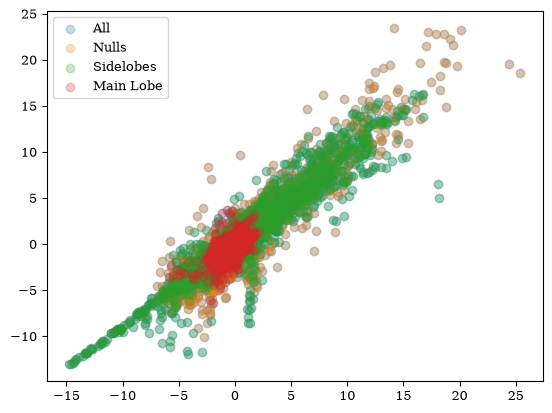

In [10]:
def points_in_square_with_hole(x, y, center=(0, 0), outer_side=0.6, inner_side=0.4):
    """
    Return x, y pairs that lie within a large square but outside a smaller
    concentric square hole.

    Parameters
    ----------
    x, y : 1D array-like
        Coordinate arrays (same length, paired by index).
    center : tuple(float, float)
        Center of both squares.
    outer_side : float
        Side length of the outer (large) square.
    inner_side : float
        Side length of the inner (small) square to exclude.

    Returns
    -------
    x_sel, y_sel : ndarray
        Filtered coordinate pairs.
    mask : ndarray of bool
        Boolean mask into the original arrays (True = kept).
    """
    x = np.asarray(x)
    y = np.asarray(y)
    cx, cy = center

    half_outer = outer_side / 2.0
    half_inner = inner_side / 2.0

    dx = np.abs(x - cx)
    dy = np.abs(y - cy)

    in_outer = (dx <= half_outer) & (dy <= half_outer)
    in_inner = (dx <= half_inner) & (dy <= half_inner)

    mask = in_outer & ~in_inner

    return x[mask], y[mask], mask


alpha = 0.25



regions = [
    ("Nulls",     0.8, 1.2),
    ("Sidelobes", 1.2, 2.0),
    ("Main Lobe", 0.0, 0.8),
]


chunk_num0 = 2
chunk_num1 = 3

plt.scatter(chunk_models[chunk_num0], chunk_models[chunk_num1], label="All", alpha=alpha)

masks = {}
for label, inner_side, outer_side in regions:
    _, _, masks[label] = points_in_square_with_hole(
        chunk_data["xspline"], chunk_data["yspline"],
        inner_side=inner_side, outer_side=outer_side
    )

    plt.scatter(
        chunk_models[chunk_num0][masks[label]],
        chunk_models[chunk_num1][masks[label]],
        label=label,
        alpha=alpha
    )
    corr = np.corrcoef(
        chunk_models[chunk_num0][masks[label]],
        chunk_models[chunk_num1][masks[label]],
    )
    print(f"Correlation Coefficient of {label}: {corr[0, 1]}")

plt.legend()

In [11]:
scatter_samps = jax.vmap(lambda x: scatter_coeffs(x, knot_mask, knot_ij))

one_hots = jnp.eye(Nparam)
one_hots = scatter_samps(one_hots)
chunk_lsq = 1

lsq_spl = SphericalSpline(t_x, t_y, one_hots, p, q)
Dmatr = eval_spline_samples(
    lsq_spl, 
    chunk_data_containers[chunk_lsq]["dat_coord_1"], 
    chunk_data_containers[chunk_lsq]["dat_coord_2"]
).T

lsq_coeff = jnp.linalg.lstsq(Dmatr, chunk_data_containers[chunk_lsq]["res"])
lsq_soln_spl = SphericalSpline(t_x, t_y, scatter_coeffs(lsq_coeff[0], knot_mask, knot_ij), p, q)

lsq_im = eval_spline_batch(lsq_soln_spl, chunk_data_containers[0]["xspline"], chunk_data_containers[0]["yspline"])

if not PLOT_RES:
    lsq_im = add_FEE_to_model(
        chunk_data_containers[chunk_lsq],
        lsq_im
    )

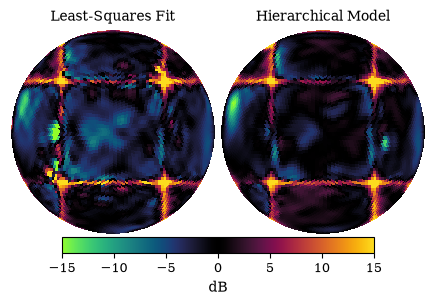

In [12]:
lsq_filled = fill_map(lsq_im, npix, chunk_data["above_horizon"])

fig = plt.figure(figsize=(4.2, 0.6 * 4.2))

lsq_orthview_kwargs = {
    "rot": (0, 90, 180),
    "half_sky": True,
    "badcolor": "white",
    "cbar": False,
}

ax = []

hp.orthview(
    lsq_filled,
    sub=(1, 2, 1),
    min=vmin,
    max=vmax,
    cmap=cmap,
    title="Least-Squares Fit",
    **lsq_orthview_kwargs
)

ax.append(plt.gca())

if PLOT_RES:
    to_plot = fill_map(chunk_models[chunk_lsq], npix, chunk_data["above_horizon"])
else:
    to_plot = add_FEE_to_model(
        chunk_data_containers[chunk_lsq],
        chunk_models[chunk_lsq]
    )
    to_plot = fill_map(to_plot, npix, chunk_data["above_horizon"])

hp.orthview(
    to_plot,
    sub=(1, 2, 2),
    min=vmin,
    max=vmax,
    title="Hierarchical Model",
    cmap=cmap,
    **lsq_orthview_kwargs
)

ax.append(plt.gca())

norm = Normalize(vmin=vmin, vmax=vmax)
norm.vmin, norm.vmax = vmin, vmax  # lock explicitly
cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap), 
    ax=ax, 
    label="dB", 
    orientation="horizontal", 
    pad=0.01,
    shrink=0.75,
)

# shrink doing crazy shit
# pos = cbar.ax.get_position()
# new_width = pos.width * 0.5
# cbar.ax.set_position([pos.x0 + (pos.width - new_width)/2, pos.y0, new_width, pos.height])

fig.savefig(f"{paper_plot_dir}/lsq_comparison_plot_res_{PLOT_RES}_chunk_{chunk_lsq}.pdf", bbox_inches="tight")



In [19]:


c1 = scatter_samps(chunked_samps[0]["surf_vals"])
c2 = scatter_samps(chunked_samps[1]["surf_vals"])

spl1 = SphericalSpline(t_x, t_y, c1, p, q)
spl2 = SphericalSpline(t_x, t_y, c2, p, q)

im1 = eval_spline_samples(spl1, chunk_data["xspline"], chunk_data["yspline"])
im2 = eval_spline_samples(spl2, chunk_data["xspline"], chunk_data["yspline"])

im1_mean = im1.mean(axis=0)
im1_std = im1.std(axis=0)

im2_mean = im2.mean(axis=0)
im2_std = im2.std(axis=0)

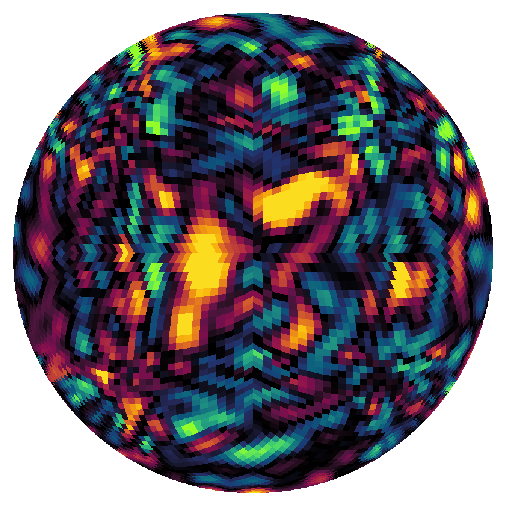

In [20]:
diff = im1_mean - im2_mean
diff_std = np.sqrt(im1_std**2 + im2_std)

hp.orthview(
    fill_map(diff/diff_std, npix, chunk_data["above_horizon"]),
    min=-5,
    max=5,
    cmap=cmr.wildfire,
    **orthview_kwargs,
)

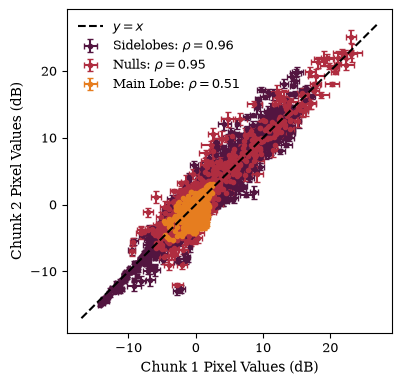

In [26]:
def weighted_corr_with_errors(x, y, sigma_x, sigma_y, rho_xy=None):
    """
    Weighted Pearson correlation coefficient for data with errors in
    both x and y.

    Weights are formed from the combined (effective) variance of each
    point, sigma_x_i^2 + sigma_y_i^2 (optionally including a known
    x-y error correlation term), so that noisier points contribute
    less to the correlation estimate. This is the standard
    "effective variance" weighting used in e.g. York-type regression.

    Parameters
    ----------
    x, y : jax.numpy.ndarray, shape (N,)
        Data points.
    sigma_x, sigma_y : jax.numpy.ndarray, shape (N,)
        1-sigma uncertainties on x and y for each point.
    rho_xy : jax.numpy.ndarray, shape (N,), optional
        Known correlation coefficient between the x and y errors for
        each point (if the errors are correlated per-point). Defaults
        to None (treated as zero).

    Returns
    -------
    r_w : float
        Weighted correlation coefficient, in [-1, 1].
    """
    x = jnp.asarray(x)
    y = jnp.asarray(y)
    sigma_x = jnp.asarray(sigma_x)
    sigma_y = jnp.asarray(sigma_y)

    # Effective variance per point combines both error sources.
    if rho_xy is None:
        eff_var = sigma_x**2 + sigma_y**2
    else:
        rho_xy = jnp.asarray(rho_xy)
        eff_var = sigma_x**2 + sigma_y**2 - 2.0 * rho_xy * sigma_x * sigma_y

    # Inverse-variance weights.
    w = 1.0 / eff_var
    w = w / jnp.sum(w)  # normalize (not strictly necessary, but tidy)

    # Weighted means.
    x_bar = jnp.sum(w * x)
    y_bar = jnp.sum(w * y)

    dx = x - x_bar
    dy = y - y_bar

    cov_xy = jnp.sum(w * dx * dy)
    var_x = jnp.sum(w * dx**2)
    var_y = jnp.sum(w * dy**2)

    r_w = cov_xy / jnp.sqrt(var_x * var_y)
    return r_w

plt.figure(figsize=(4.2, 4.2))
wildfire_top = cmr.get_sub_cmap(cmr.wildfire, 0.5, 1).with_extremes(under="white")
cval = 0.25
for region in ["Sidelobes", "Nulls", "Main Lobe"]:
    mask = masks[region]
    
    corr = weighted_corr_with_errors(
        im1_mean[mask], 
        im2_mean[mask], 
        im1_std[mask],
        im2_std[mask]
    )
    #corr = jnp.corrcoef(im1_mean[mask], im2_mean[mask])[0, 1]
    plt.errorbar(
        im1_mean[mask], 
        im2_mean[mask], 
        xerr=im1_std[mask], 
        yerr=im2_std[mask], 
        linestyle="none", 
        marker=".",
        label=fr"{region}: $\rho={corr:.2f}$",
        capsize=2,
        color=wildfire_top(cval),
    )
    cval += 0.25

xplot = np.linspace(-17, 27, num=100)
plt.plot(xplot, xplot, linestyle="--", color="black", label=r"$y = x$", zorder=4)
plt.xlabel("Chunk 1 Pixel Values (dB)")
plt.ylabel("Chunk 2 Pixel Values (dB)")
plt.legend(frameon=False)
plt.savefig(f"{paper_plot_dir}/chunk_corr_plot.pdf", bbox_inches="tight")